# Algoritmo de Deutsch — Implementación en Qiskit

**Proyecto:** Avance / Expediente técnico — Fundamentos de Computación Cuántica  
**Alumnos:** Axcel Francisco Salazar Alejo, Viker Alberto Guajardo Diaz

Este notebook implementa, en Qiskit, el **diseño final del circuito** descrito en el expediente técnico: dos qubits (uno de entrada y uno auxiliar), compuertas Hadamard, un oráculo cuántico $U_f$ y una medición final sobre el qubit de entrada.

Se corre el circuito para las **cuatro funciones posibles** de la caja negra (dos constantes y dos balanceadas) y se comparan los resultados con la simulación clásica equivalente, para verificar la ventaja cuántica: **1 consulta** al oráculo en vez de **2**.

## 1. Instalación de dependencias (solo la primera vez en Colab)

In [ ]:
!pip install -q qiskit qiskit-aer pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.4 MB/s eta 0:00:00


## 2. Importaciones

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

## 3. Definición del oráculo $U_f$

Se define un circuito de 2 qubits por cada una de las cuatro funciones posibles de la caja negra. El qubit 0 es la entrada y el qubit 1 es el auxiliar. Estas cuatro variantes corresponden exactamente a las descritas en la sección *Diseño final del circuito* del expediente.

In [ ]:
def oraculo_constante_0():
    """f(x) = 0 para todo x -> Uf no aplica ninguna compuerta."""
    qc = QuantumCircuit(2, name="Uf: constante 0")
    return qc

def oraculo_constante_1():
    """f(x) = 1 para todo x -> Uf aplica X al auxiliar, sin condicionarla al de entrada."""
    qc = QuantumCircuit(2, name="Uf: constante 1")
    qc.x(1)
    return qc

def oraculo_balanceada_identidad():
    """f(x) = x -> Uf aplica un CNOT controlado por el qubit de entrada."""
    qc = QuantumCircuit(2, name="Uf: balanceada (f=x)")
    qc.cx(0, 1)
    return qc

def oraculo_balanceada_negada():
    """f(x) = NOT x -> Uf combina el CNOT anterior con una X adicional sobre el auxiliar."""
    qc = QuantumCircuit(2, name="Uf: balanceada (f=NOT x)")
    qc.cx(0, 1)
    qc.x(1)
    return qc

oraculos = {
    "Constante (f=0)": oraculo_constante_0(),
    "Constante (f=1)": oraculo_constante_1(),
    "Balanceada (f=x)": oraculo_balanceada_identidad(),
    "Balanceada (f=NOT x)": oraculo_balanceada_negada(),
}

## 4. Construcción del circuito completo del algoritmo de Deutsch

Sigue exactamente la secuencia del diseño final:
1. Inicializar q0 y q1 en el estado 0.
2. Aplicar X al qubit auxiliar (q1), para dejarlo en el estado 1.
3. Aplicar Hadamard a ambos qubits.
4. Aplicar una sola vez el oráculo $U_f$.
5. Aplicar una segunda Hadamard, solo al qubit de entrada (q0).
6. Medir el qubit de entrada (q0).

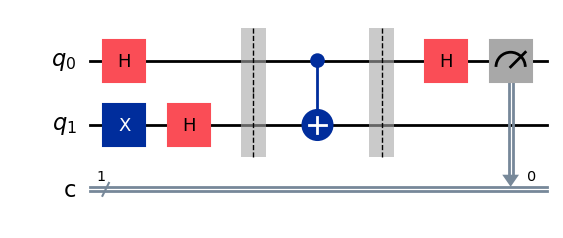

In [ ]:
import sys
if 'pylatexenc' not in sys.modules:
    !pip install -q pylatexenc
def circuito_deutsch(oraculo):
    qc = QuantumCircuit(2, 1)
    qc.x(1)
    qc.h(0)
    qc.h(1)
    qc.barrier()
    qc.compose(oraculo, inplace=True)
    qc.barrier()
    qc.h(0)
    qc.measure(0, 0)
    return qc

# Ejemplo: circuito completo para la función balanceada f(x) = x
ejemplo = circuito_deutsch(oraculos["Balanceada (f=x)"])
ejemplo.draw("mpl")

## 5. Ejecución en el simulador para las cuatro funciones posibles

In [ ]:
simulador = AerSimulator()
resultados_cuanticos = {}

for nombre, oraculo in oraculos.items():
    qc = circuito_deutsch(oraculo)
    qc_transpilado = transpile(qc, simulador)
    resultado = simulador.run(qc_transpilado, shots=100).result()
    counts = resultado.get_counts()
    bit_medido = max(counts, key=counts.get)
    tipo_obtenido = "Constante" if bit_medido == "0" else "Balanceada"
    tipo_real = "Constante" if nombre.startswith("Constante") else "Balanceada"

    resultados_cuanticos[nombre] = {
        "counts": counts,
        "bit_medido": bit_medido,
        "tipo_obtenido": tipo_obtenido,
        "acierto": tipo_obtenido == tipo_real,
        "consultas": 1,
    }

### 5.1 Extensión a k = 2 qubits de entrada

Mismo esquema, pero ahora con **2 qubits de entrada** (+ 1 auxiliar). El oráculo balanceado usado aquí es la paridad x1 XOR x2. Igual que arriba, se corre **100 veces**; la clasificación (Constante/Balanceada) de estas corridas se muestra junto con la comparación clásica en la sección 7.

In [ ]:
def oraculo_constante_k2(valor=0):
    """f(x1, x2) = valor para todo x -> 2 qubits de entrada + 1 auxiliar."""
    qc = QuantumCircuit(3, name=f"Uf: constante {valor} (k=2)")
    if valor == 1:
        qc.x(2)
    return qc

def oraculo_balanceada_k2():
    """f(x1, x2) = x1 XOR x2 -> balanceada, 2 qubits de entrada + 1 auxiliar."""
    qc = QuantumCircuit(3, name="Uf: balanceada paridad (k=2)")
    qc.cx(0, 2)
    qc.cx(1, 2)
    return qc

def circuito_deutsch_k2(oraculo):
    qc = QuantumCircuit(3, 2)
    qc.x(2)
    qc.h([0, 1, 2])
    qc.barrier()
    qc.compose(oraculo, inplace=True)
    qc.barrier()
    qc.h([0, 1])
    qc.measure([0, 1], [0, 1])
    return qc

oraculos_k2 = {
    "Constante (f=0), k=2": oraculo_constante_k2(0),
    "Constante (f=1), k=2": oraculo_constante_k2(1),
    "Balanceada (x1 XOR x2), k=2": oraculo_balanceada_k2(),
}

resultados_cuanticos_k2 = {}

for nombre, oraculo in oraculos_k2.items():
    qc = circuito_deutsch_k2(oraculo)
    qc_transpilado = transpile(qc, simulador)
    resultado = simulador.run(qc_transpilado, shots=100).result()
    counts = resultado.get_counts()

    es_constante = counts.get("00", 0) == 100
    tipo_obtenido = "Constante" if es_constante else "Balanceada"
    tipo_real = "Constante" if nombre.startswith("Constante") else "Balanceada"

    resultados_cuanticos_k2[nombre] = {
        "counts": counts,
        "tipo_obtenido": tipo_obtenido,
        "acierto": tipo_obtenido == tipo_real,
        "consultas": 1,
    }

### 5.2 Extensión a k = 3 qubits de entrada

Mismo esquema, ahora con **3 qubits de entrada** (+ 1 auxiliar). El oráculo balanceado es la paridad x1 XOR x2 XOR x3. Igual que arriba, se corre **100 veces**; la clasificación se muestra junto con la comparación clásica en la sección 7.

In [ ]:
def oraculo_constante_k3(valor=0):
    """f(x1, x2, x3) = valor para todo x -> 3 qubits de entrada + 1 auxiliar."""
    qc = QuantumCircuit(4, name=f"Uf: constante {valor} (k=3)")
    if valor == 1:
        qc.x(3)
    return qc

def oraculo_balanceada_k3():
    """f(x1, x2, x3) = x1 XOR x2 XOR x3 -> balanceada, 3 qubits de entrada + 1 auxiliar."""
    qc = QuantumCircuit(4, name="Uf: balanceada paridad (k=3)")
    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)
    return qc

def circuito_deutsch_k3(oraculo):
    qc = QuantumCircuit(4, 3)
    qc.x(3)
    qc.h([0, 1, 2, 3])
    qc.barrier()
    qc.compose(oraculo, inplace=True)
    qc.barrier()
    qc.h([0, 1, 2])
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc

oraculos_k3 = {
    "Constante (f=0), k=3": oraculo_constante_k3(0),
    "Constante (f=1), k=3": oraculo_constante_k3(1),
    "Balanceada (x1 XOR x2 XOR x3), k=3": oraculo_balanceada_k3(),
}

resultados_cuanticos_k3 = {}

for nombre, oraculo in oraculos_k3.items():
    qc = circuito_deutsch_k3(oraculo)
    qc_transpilado = transpile(qc, simulador)
    resultado = simulador.run(qc_transpilado, shots=100).result()
    counts = resultado.get_counts()

    es_constante = counts.get("000", 0) == 100
    tipo_obtenido = "Constante" if es_constante else "Balanceada"
    tipo_real = "Constante" if nombre.startswith("Constante") else "Balanceada"

    resultados_cuanticos_k3[nombre] = {
        "counts": counts,
        "tipo_obtenido": tipo_obtenido,
        "acierto": tipo_obtenido == tipo_real,
        "consultas": 1,
    }

## 6. Histograma de resultados

Para el algoritmo de Deutsch, en un simulador ideal (sin ruido) el resultado debe ser **determinista**: las 100 mediciones deben caer en un único valor (0 o 1) para cada función, sin dispersión entre ambos.

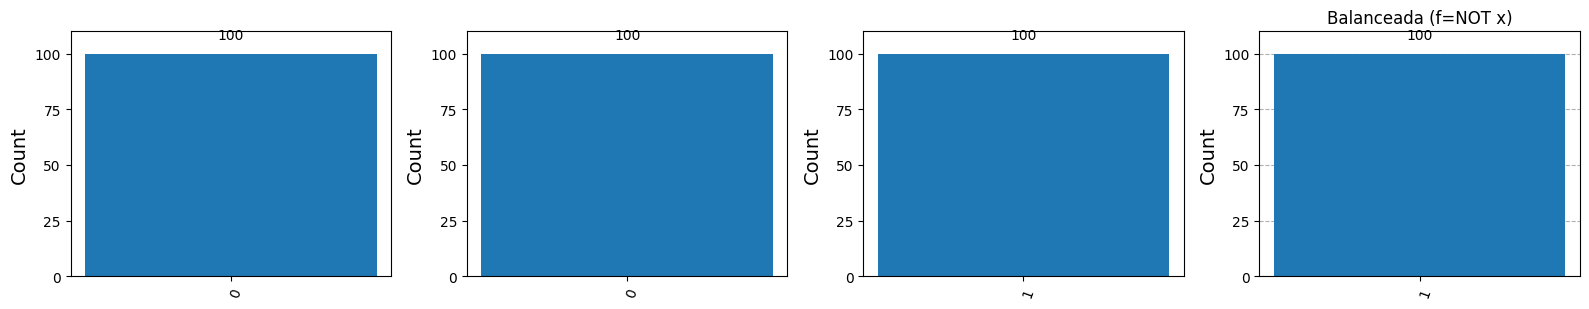

In [ ]:
fig, ejes = plt.subplots(1, 4, figsize=(16, 3.2))
for eje, (nombre, datos) in zip(ejes, resultados_cuanticos.items()):
    plot_histogram(datos["counts"], ax=eje, title=nombre)
plt.tight_layout()
plt.show()

## 7. Comparación con el método clásico

Se reutiliza la lógica de la simulación clásica del avance previo (2 consultas siempre) para comparar directamente contra los resultados cuánticos obtenidos arriba.

In [ ]:
def f_constante_0(x): return 0
def f_constante_1(x): return 1
def f_identidad(x): return x
def f_negada(x): return 1 - x

funciones_clasicas = {
    "Constante (f=0)": f_constante_0,
    "Constante (f=1)": f_constante_1,
    "Balanceada (f=x)": f_identidad,
    "Balanceada (f=NOT x)": f_negada,
}

def resolver_clasico(f):
    f0 = f(0)
    f1 = f(1)
    tipo = "Constante" if f0 == f1 else "Balanceada"
    return tipo, 2  # siempre 2 consultas

print(f"{'Función':22s}{'Clásico (tipo / consultas)':32s}{'Cuántico (tipo / consultas)'}")
for nombre in funciones_clasicas:
    tipo_c, consultas_c = resolver_clasico(funciones_clasicas[nombre])
    tipo_q = resultados_cuanticos[nombre]["tipo_obtenido"]
    consultas_q = resultados_cuanticos[nombre]["consultas"]
    print(f"{nombre:22s}{tipo_c + ' / ' + str(consultas_c):32s}{tipo_q} / {consultas_q}")

# --- Mismo formato de tabla, ahora para k = 2 (algoritmo de Deutsch-Jozsa) ---
# Clásico, peor caso para k qubits de entrada: 2^(k-1) + 1 consultas
def f2_constante_0(x1, x2): return 0
def f2_constante_1(x1, x2): return 1
def f2_xor(x1, x2): return x1 ^ x2

funciones_clasicas_k2 = {
    "Constante (f=0), k=2": f2_constante_0,
    "Constante (f=1), k=2": f2_constante_1,
    "Balanceada (x1 XOR x2), k=2": f2_xor,
}

def resolver_clasico_k2(f):
    valores = [f(x1, x2) for x1 in (0, 1) for x2 in (0, 1)]
    tipo = "Constante" if len(set(valores)) == 1 else "Balanceada"
    consultas = 2 ** (2 - 1) + 1  # peor caso clásico para k=2 -> 3 consultas
    return tipo, consultas

print()
print(f"{'Función':30s}{'Clásico (tipo / consultas)':32s}{'Cuántico (tipo / consultas)'}")
for nombre in funciones_clasicas_k2:
    tipo_c, consultas_c = resolver_clasico_k2(funciones_clasicas_k2[nombre])
    tipo_q = resultados_cuanticos_k2[nombre]["tipo_obtenido"]
    consultas_q = resultados_cuanticos_k2[nombre]["consultas"]
    print(f"{nombre:30s}{tipo_c + ' / ' + str(consultas_c):32s}{tipo_q} / {consultas_q}")

# --- Mismo formato de tabla, ahora para k = 3 ---
def f3_constante_0(x1, x2, x3): return 0
def f3_constante_1(x1, x2, x3): return 1
def f3_xor(x1, x2, x3): return x1 ^ x2 ^ x3

funciones_clasicas_k3 = {
    "Constante (f=0), k=3": f3_constante_0,
    "Constante (f=1), k=3": f3_constante_1,
    "Balanceada (x1 XOR x2 XOR x3), k=3": f3_xor,
}

def resolver_clasico_k3(f):
    valores = [f(x1, x2, x3) for x1 in (0, 1) for x2 in (0, 1) for x3 in (0, 1)]
    tipo = "Constante" if len(set(valores)) == 1 else "Balanceada"
    consultas = 2 ** (3 - 1) + 1  # peor caso clásico para k=3 -> 5 consultas
    return tipo, consultas

print()
print(f"{'Función':36s}{'Clásico (tipo / consultas)':32s}{'Cuántico (tipo / consultas)'}")
for nombre in funciones_clasicas_k3:
    tipo_c, consultas_c = resolver_clasico_k3(funciones_clasicas_k3[nombre])
    tipo_q = resultados_cuanticos_k3[nombre]["tipo_obtenido"]
    consultas_q = resultados_cuanticos_k3[nombre]["consultas"]
    print(f"{nombre:36s}{tipo_c + ' / ' + str(consultas_c):32s}{tipo_q} / {consultas_q}")

Función               Clásico (tipo / consultas)      Cuántico (tipo / consultas)
Constante (f=0)       Constante / 2                   Constante / 1
Constante (f=1)       Constante / 2                   Constante / 1
Balanceada (f=x)      Balanceada / 2                  Balanceada / 1
Balanceada (f=NOT x)  Balanceada / 2                  Balanceada / 1

Función                       Clásico (tipo / consultas)      Cuántico (tipo / consultas)
Constante (f=0), k=2          Constante / 3                   Constante / 1
Constante (f=1), k=2          Constante / 3                   Constante / 1
Balanceada (x1 XOR x2), k=2   Balanceada / 3                  Balanceada / 1

Función                             Clásico (tipo / consultas)      Cuántico (tipo / consultas)
Constante (f=0), k=3                Constante / 5                   Constante / 1
Constante (f=1), k=3                Constante / 5                   Constante / 1
Balanceada (x1 XOR x2 XOR x3), k=3  Balanceada / 5             

## 8. Versión manual: eliges tú los qubits (k) y las corridas (shots)

Esta celda es genérica para **cualquier k** (no solo 1, 2 o 3): te pregunta cuántos qubits de entrada quieres usar y cuántas corridas (shots) quieres hacer, y corre el algoritmo de Deutsch–Jozsa con esos valores para las funciones constante (f=0), constante (f=1) y balanceada (paridad).

Al ejecutar la celda en Colab van a aparecer dos cuadros de texto arriba de la celda: uno para `k` y otro para `shots`. Escribe el número y presiona Enter.

In [ ]:

def oraculo_constante_generico(k, valor=0):
    """f(x) = valor para todo x, con k qubits de entrada (+ 1 auxiliar)."""
    qc = QuantumCircuit(k + 1, name=f"Uf: constante {valor} (k={k})")
    if valor == 1:
        qc.x(k)
    return qc

def oraculo_balanceada_generico(k):
    """f(x) = paridad de x (XOR de todos los bits de entrada) -> balanceada para cualquier k."""
    qc = QuantumCircuit(k + 1, name=f"Uf: balanceada paridad (k={k})")
    for i in range(k):
        qc.cx(i, k)
    return qc

def circuito_deutsch_jozsa_generico(k, oraculo):
    qc = QuantumCircuit(k + 1, k)
    qc.x(k)                 # qubit auxiliar en |1>
    qc.h(range(k + 1))      # Hadamard a entrada + auxiliar
    qc.barrier()
    qc.compose(oraculo, inplace=True)
    qc.barrier()
    qc.h(range(k))           # Hadamard solo a los qubits de entrada
    qc.measure(range(k), range(k))
    return qc

# --- Aquí escribes tú los valores que quieras probar ---
k = int(input("¿Cuántos qubits de entrada (k) quieres usar? "))
shots = int(input("¿Cuántas corridas (shots) quieres hacer? "))

oraculos_manual = {
    f"Constante (f=0), k={k}": oraculo_constante_generico(k, 0),
    f"Constante (f=1), k={k}": oraculo_constante_generico(k, 1),
    f"Balanceada (paridad), k={k}": oraculo_balanceada_generico(k),
}

resultados_manual = {}
cadena_ceros = "0" * k

for nombre, oraculo in oraculos_manual.items():
    qc = circuito_deutsch_jozsa_generico(k, oraculo)
    qc_transpilado = transpile(qc, simulador)
    resultado = simulador.run(qc_transpilado, shots=shots).result()
    counts = resultado.get_counts()

    cantidad_constante = counts.get(cadena_ceros, 0)
    cantidad_balanceada = shots - cantidad_constante
    tipo_obtenido = "Constante" if cantidad_constante == shots else "Balanceada"
    tipo_real = "Constante" if nombre.startswith("Constante") else "Balanceada"

    resultados_manual[nombre] = {
        "counts": counts,
        "tipo_obtenido": tipo_obtenido,
        "acierto": tipo_obtenido == tipo_real,
        "cantidad_constante": cantidad_constante,
        "cantidad_balanceada": cantidad_balanceada,
    }

ancho_nombre = max(len(n) for n in resultados_manual) + 2
consultas_clasicas = 2 ** (k - 1) + 1

print()
print(f"{'Función':<{ancho_nombre}}{'Clásico (tipo / consultas)':32s}{'Cuántico (tipo / consultas)'}")
for nombre, datos in resultados_manual.items():
    tipo_c = "Constante" if nombre.startswith("Constante") else "Balanceada"
    fila_c = f"{tipo_c} / {consultas_clasicas}"
    print(f"{nombre:<{ancho_nombre}}{fila_c:32s}{datos['tipo_obtenido']} / 1")

print()
print(f"De las {shots} corridas por función:")
for nombre, datos in resultados_manual.items():
    print(f"  {nombre:<{ancho_nombre}} Constante={datos['cantidad_constante']}  "
          f"Balanceada={datos['cantidad_balanceada']}")

¿Cuántos qubits de entrada (k) quieres usar? 3
¿Cuántas corridas (shots) quieres hacer? 300

Función                    Clásico (tipo / consultas)      Cuántico (tipo / consultas)
Constante (f=0), k=3       Constante / 5                   Constante / 1
Constante (f=1), k=3       Constante / 5                   Constante / 1
Balanceada (paridad), k=3  Balanceada / 5                  Balanceada / 1

De las 300 corridas por función:
  Constante (f=0), k=3        Constante=300  Balanceada=0
  Constante (f=1), k=3        Constante=300  Balanceada=0
  Balanceada (paridad), k=3   Constante=0  Balanceada=300


## 9. Conclusión de esta corrida

- El método **clásico** siempre necesita **2 consultas** a la caja, sin importar la función.
- El método **cuántico** (algoritmo de Deutsch) siempre necesita **1 sola consulta**, y clasifica correctamente las cuatro funciones posibles en el simulador ideal (100% de exactitud, sin ruido).
- Esto confirma, ya con un circuito real construido en Qiskit, la ventaja cuántica que se había anticipado teóricamente en el marco conceptual y en la comparación clásica-cuántica del expediente.

**Siguientes pasos (para la etapa de resultados / metodología experimental):** repetir esta ejecución usando un modelo de ruido (`qiskit_aer.noise`) para observar si la exactitud se mantiene en un entorno menos ideal, y documentar el backend, los shots y los parámetros usados.